In [2]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["TotalCharges"].dtype

dtype('O')

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [8]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [9]:
df = df.dropna(subset=["TotalCharges"])

In [10]:
df.shape

(7032, 21)

In [11]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


In [12]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


In [13]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [14]:
df["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


In [15]:
df = df.drop("customerID", axis=1)

In [16]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [17]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 19)
y shape: (7032,)


In [18]:
X.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [19]:
X = pd.get_dummies(X, drop_first=True)


In [20]:
print(X.head())
print(y.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False              False  ...   
3               

In [21]:
from sklearn.model_selection import train_test_split

# Convert True/False columns into 1/0
X = X.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


In [22]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)

Accuracy : 0.8024164889836531
Precision: 0.6454545454545455
Recall   : 0.56951871657754


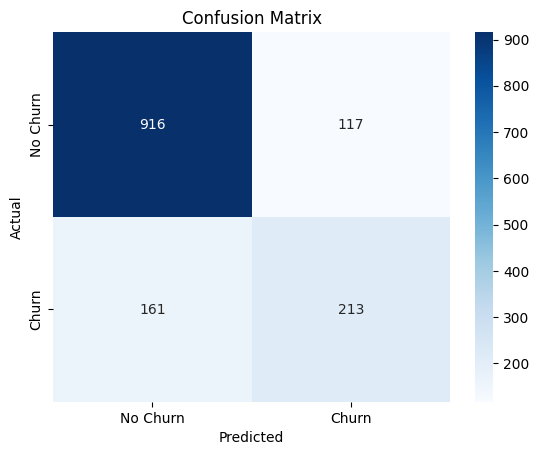

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [26]:
# Get the model coefficients
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

# Add absolute value so we can find the strongest drivers
coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

# Top 5 drivers
top_5_drivers = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(5)

top_5_drivers

,Feature,Coefficient,Absolute_Coefficient
25,Contract_Two year,-1.365224,1.365224
24,Contract_One year,-0.745011,0.745011
10,InternetService_Fiber optic,0.663445,0.663445
13,OnlineSecurity_Yes,-0.461459,0.461459
7,PhoneService_Yes,-0.459728,0.459728


In [27]:
top_5_drivers["Impact"] = ""

for i in range(len(top_5_drivers)):
    if top_5_drivers.iloc[i]["Coefficient"] > 0:
        top_5_drivers.iloc[i, top_5_drivers.columns.get_loc("Impact")] = "Higher churn"
    else:
        top_5_drivers.iloc[i, top_5_drivers.columns.get_loc("Impact")] = "Lower churn"

top_5_drivers

,Feature,Coefficient,Absolute_Coefficient,Impact
25,Contract_Two year,-1.365224,1.365224,Lower churn
24,Contract_One year,-0.745011,0.745011,Lower churn
10,InternetService_Fiber optic,0.663445,0.663445,Higher churn
13,OnlineSecurity_Yes,-0.461459,0.461459,Lower churn
7,PhoneService_Yes,-0.459728,0.459728,Lower churn


In [30]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [31]:
y_pred_balanced = balanced_model.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall:", recall_score(y_test, y_pred_balanced))

Accuracy: 0.728500355366027
Precision: 0.4933993399339934
Recall: 0.7994652406417112


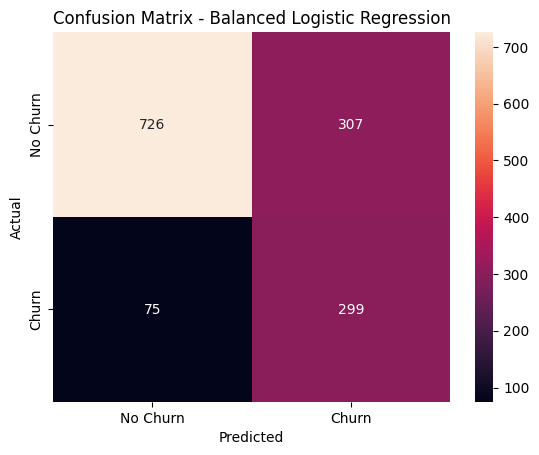

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_balanced)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.show()

In [35]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall"],
    "Original Model": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred)
    ],
    "Balanced Model": [
        accuracy_score(y_test, y_pred_balanced),
        precision_score(y_test, y_pred_balanced),
        recall_score(y_test, y_pred_balanced)
    ]
})

results

,Metric,Original Model,Balanced Model
0,Accuracy,0.802416,0.728500
1,Precision,0.645455,0.493399
2,Recall,0.569519,0.799465


In [36]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": balanced_model.coef_[0]
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

top_5_drivers = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(5)

top_5_drivers

,Feature,Coefficient,Absolute_Coefficient
25,Contract_Two year,-1.462368,1.462368
24,Contract_One year,-0.791216,0.791216
8,MultipleLines_No phone service,0.535215,0.535215
13,OnlineSecurity_Yes,-0.496827,0.496827
19,TechSupport_Yes,-0.457605,0.457605
